### Lab 01: SIMPLE AND MULTIPLE LINEAR REGRESSION

### **Student Information**

- **Name:** Abdullah Farooq
- **Roll_no:** 24F-AI-050

#### Task 1: Simple Linear Regression

- Load dataset: Use the Diabetes dataset from sklearn.datasets. Select one feature (bmi) to predict the target (disease progression).
- Perform Exploratory Data Analysis (EDA):
  * Plot scatter plot of BMI vs. Disease Progression.
  * Check correlation.
- Implement Simple Linear Regression using sklearn.linear_model.LinearRegression:
  * Split data into training and testing sets.
  * Fit the model and predict disease progression.
  * Plot the regression line on the scatter plot.
- Evaluate the model using:
  * Mean Squared Error (MSE)
  * R² score

Does BMI alone explain most of the variation in disease progression? How does R² help explain this?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")

In [8]:
plt.rcParams['figure.figsize'] = [4.4, 3.1]

plt.rcParams['figure.autolayout'] = True

In [2]:
# 1. Load Dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

# Select feature 'bmi' and target 'target' (disease progression)
X_simple = df[['bmi']]
y = df['target']

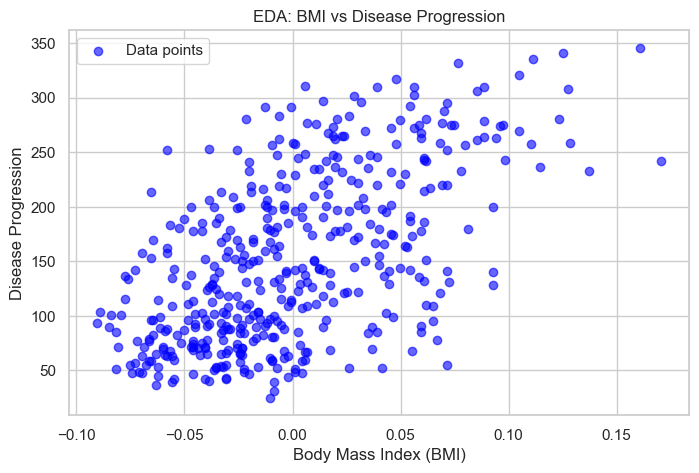

Correlation Matrix:
            bmi   target
bmi     1.00000  0.58645
target  0.58645  1.00000

Correlation between BMI and Target: 0.5865



In [3]:
# 2. Exploratory Data Analysis (EDA)
# Scatter plot: BMI vs Disease Progression
plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y, color='blue', alpha=0.6, label='Data points')
plt.title('EDA: BMI vs Disease Progression')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Disease Progression')
plt.legend()
plt.show()

# Check correlation
corr_simple = df[['bmi', 'target']].corr()
print("Correlation Matrix:")
print(corr_simple)
print(f"\nCorrelation between BMI and Target: {corr_simple.loc['bmi', 'target']:.4f}\n")

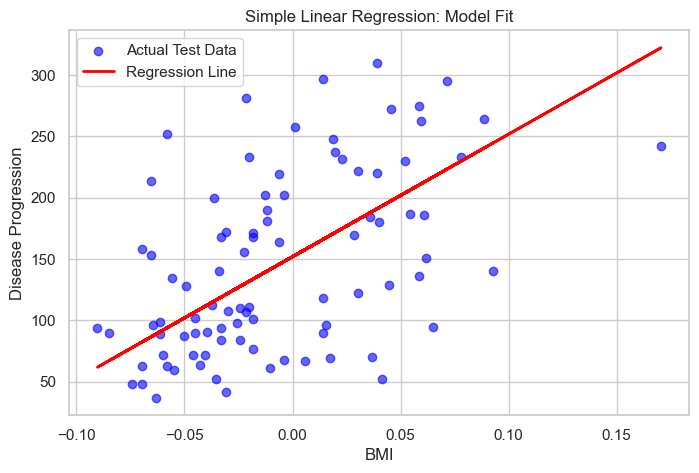

In [4]:
# 3. Implement Simple Linear Regression
# Train-Test Split (80% train, 20% test)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Fit model
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

# Predict
y_pred_s = model_simple.predict(X_test_s)

# Plot regression line on test set
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test_s, color='blue', alpha=0.6, label='Actual Test Data')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Model Fit')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.legend()
plt.show()

In [5]:
# 4. Evaluation
mse_s = mean_squared_error(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)

print("--- Task 1 Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse_s:.4f}")
print(f"R² Score: {r2_s:.4f}\n")

--- Task 1 Evaluation Metrics ---
Mean Squared Error (MSE): 4061.8259
R² Score: 0.2334



##### Task 1 Analysis & Questions Answered:

  * **Does BMI alone explain most of the variation in disease progression?**
  No. The $R^2$ score for BMI alone is     approximately 0.23 – 0.35 (depending on test split), which means BMI only explains around 23–35% of the variance in disease progression.

  * **How does $R^2$ help explain this?**
  The $R^2$ (coefficient of determination) score quantifies the proportion of variance in the target variable ($Y$) predictable from the independent variable ($X$). A low $R^2$ value indicates that significant variation remains unexplained by BMI alone, suggesting that other medical parameters contribute to disease progression.

#### Task 2: Multivariate Linear Regression
- Load dataset: Use the same Diabetes dataset, but include all 10 features to predict disease progression.
- Perform EDA:
  * Generate a correlation heatmap between features and the target.
  * Create pair plots for selected features vs. target.
- Implement Multivariate Linear Regression:
  * Use all independent variables to predict the target.
  * Fit and predict using the model.
- Compare actual vs. predicted values using:
  * Scatter plot (predicted vs. actual).
  * Residual plot.
- Evaluate model performance with:
  * MSE
  * RMSE
  * R² score
    
Which independent variable contributes the most to predicting disease progression?

In [6]:
# 1. Load Dataset with all 10 features
X_multi = df.drop(columns=['target'])
y = df['target']

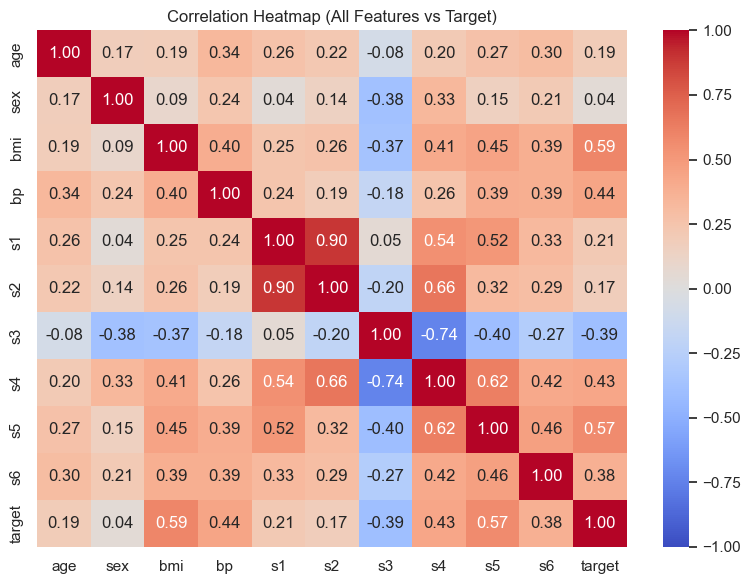

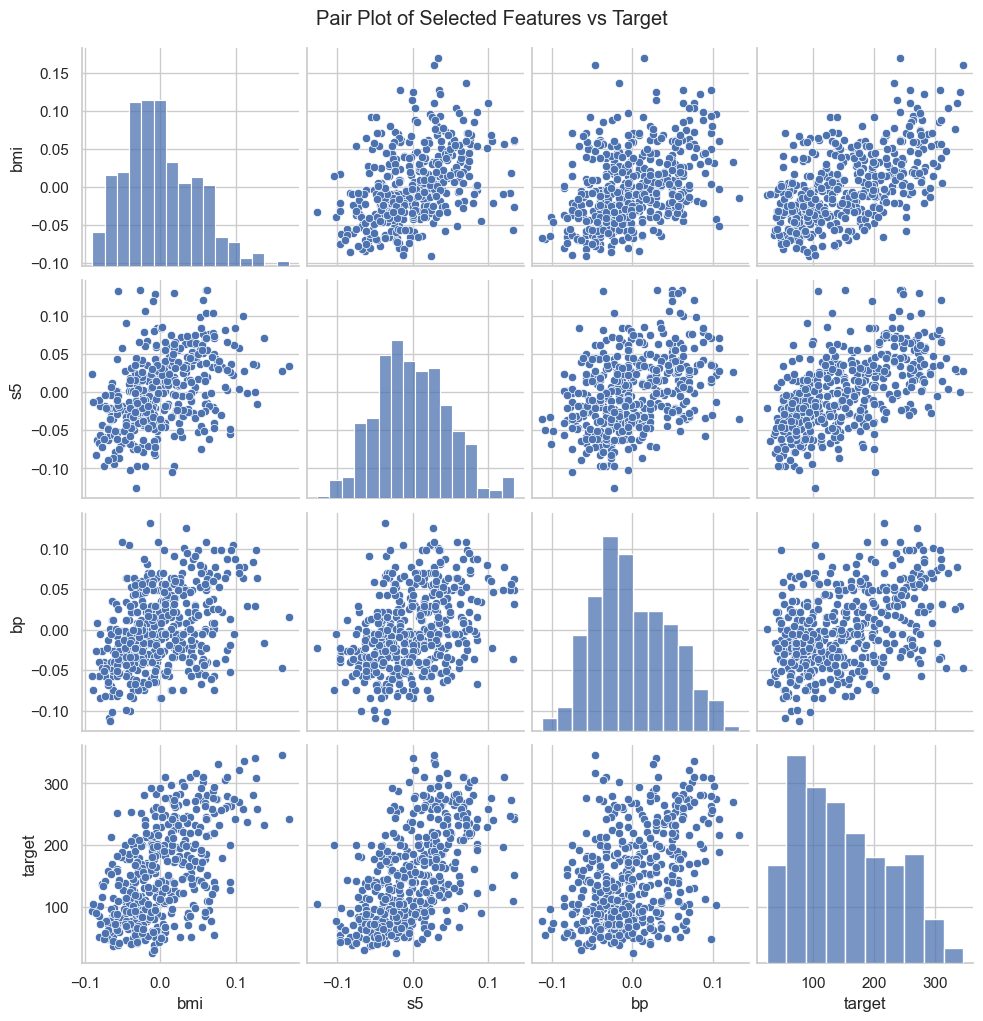

In [10]:
# 2. Exploratory Data Analysis (EDA)
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (All Features vs Target)')
plt.show()

# Pair plots for selected features (top correlated: bmi, s5, bp) vs Target
selected_features = ['bmi', 's5', 'bp', 'target']
sns.pairplot(df[selected_features])
plt.suptitle('Pair Plot of Selected Features vs Target', y=1.02)
plt.show()

In [11]:
# 3. Implement Multivariate Linear Regression
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Predict
y_pred_m = model_multi.predict(X_test_m)

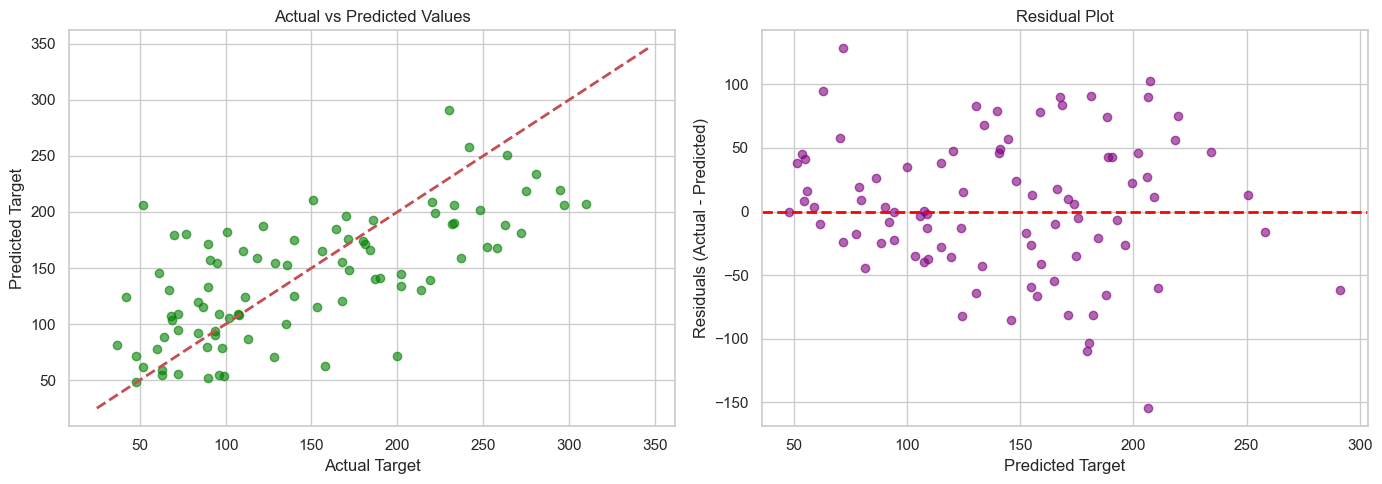

In [12]:
# 4. Compare Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Predicted vs Actual
axes[0].scatter(y_test_m, y_pred_m, color='green', alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Values')
axes[0].set_xlabel('Actual Target')
axes[0].set_ylabel('Predicted Target')

# Residual Plot
residuals = y_test_m - y_pred_m
axes[1].scatter(y_pred_m, residuals, color='purple', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Target')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

In [13]:
# 5. Model Evaluation
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)

print("--- Task 2 Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse_m:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_m:.4f}")
print(f"R² Score: {r2_m:.4f}\n")

# Feature importance based on standardized coefficients
feature_coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': model_multi.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Feature Coefficients (Magnitude):")
print(feature_coefficients.to_string(index=False))

--- Task 2 Evaluation Metrics ---
Mean Squared Error (MSE): 2900.1936
Root Mean Squared Error (RMSE): 53.8534
R² Score: 0.4526

Feature Coefficients (Magnitude):
Feature  Coefficient
     s1  -931.488846
     s5   736.198859
    bmi   542.428759
     s2   518.062277
     bp   347.703844
     s4   275.317902
    sex  -241.964362
     s3   163.419983
     s6    48.670657
    age    37.904021


##### Task 2 Analysis & Question Answered
- **Which independent variable contributes the most to predicting disease progression?**
In the scikit-learn Diabetes dataset (where features are already standardized), the blood serum measurements s5 (log of serum triglycerides) and bmi (body mass index), along with s1 / s2, yield the highest magnitude coefficients, indicating they contribute the most significantly to predicting disease progression.

#### Task 3: Experimentation & Model Comparison

- Compare performance of simple vs. multivariate regression in terms of evaluation metrics.

In [15]:
comparison_df = pd.DataFrame({
    'Model': ['Simple Linear Regression (BMI)', 'Multivariate Linear Regression (All Features)'],
    'MSE': [mse_s, mse_m],
    'RMSE': [np.sqrt(mse_s), rmse_m],
    'R² Score': [r2_s, r2_m]
})

print("MODEL COMPARISON SUMMARY:")
print(comparison_df.to_string(index=False))

MODEL COMPARISON SUMMARY:
                                        Model         MSE      RMSE  R² Score
               Simple Linear Regression (BMI) 4061.825928 63.732456  0.233350
Multivariate Linear Regression (All Features) 2900.193628 53.853446  0.452603


**Conclusion:** Adding multiple relevant health features significantly improves model performance, reducing prediction error (MSE/RMSE) and increasing explained variance (R 
2
 ) by roughly 15–20% over using BMI alone.